In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
import os

# Add parent directory to Python path
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)


from larndsim import consts
consts.load_properties(
    detprop_file='../larndsim/detector_properties/2x2.yaml',
    pixel_file='../larndsim/pixel_layouts/multi_tile_layout-2.3.16.yaml',
    response_file=None,
    sim_file='../larndsim/simulation_properties/singles_sim.yaml'
)

print("Detector configuration loaded successfully!")

Detector configuration loaded successfully!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
import h5py

from larndsim.consts import detector, ff_induction
from larndsim.far_field import PixelCategory
from larndsim.far_field.pixel_classifier import (
    classify_pixels,
    generate_pixel_coordinates
)

# %matplotlib widget

print(f"Detector loaded: {len(detector.TPC_BORDERS)} TPC planes")
print(f"Pixel grid: {detector.N_PIXELS[0]} x {detector.N_PIXELS[1]} pixels")
print(f"Pixel pitch: {detector.PIXEL_PITCH} cm")
print(f"Mesh refinement modules loaded successfully")

Detector loaded: 8 TPC planes
Pixel grid: 140 x 280 pixels
Pixel pitch: 0.4434 cm
Mesh refinement modules loaded successfully


In [3]:
# Actually loading a larnd-sim output since I need n_electrons and pixel_plane info
edep_file = '/global/cfs/cdirs/dune/www/data/2x2/simulation/productions/MiniRun6.5_1E19_RHC/MiniRun6.5_1E19_RHC.larnd/LARNDSIM/0000000/MiniRun6.5_1E19_RHC.larnd.0000000.LARNDSIM.hdf5'  # Update this path

print(f"Loading edep-sim data from: {edep_file}")

Loading edep-sim data from: /global/cfs/cdirs/dune/www/data/2x2/simulation/productions/MiniRun6.5_1E19_RHC/MiniRun6.5_1E19_RHC.larnd/LARNDSIM/0000000/MiniRun6.5_1E19_RHC.larnd.0000000.LARNDSIM.hdf5


In [4]:
# Load segments from HDF5 file
with h5py.File(edep_file, 'r') as f:
    # Load segments dataset
    all_segments = f['segments'][:]
    
    print(f"Loaded {len(all_segments)} total segments")


Loaded 72776 total segments


In [5]:
# Get event_ids/TPCs with the highest number of segments
uid, counts = np.unique(all_segments['event_id']*10 + all_segments['pixel_plane'], return_counts=True)
k = 10
inds = np.argsort(counts)[-k::]
print(f"The top {k} (event_id, pixel_plane) with the largest number of segments are: ")
for i in inds[::-1]:
    print(f'({uid[i]//10}, {uid[i]%10}): {counts[i]} segments')


The top 10 (event_id, pixel_plane) with the largest number of segments are: 
(138, 0): 4228 segments
(157, 2): 2033 segments
(27, 7): 1682 segments
(181, 3): 1286 segments
(138, 1): 1119 segments
(76, 2): 1047 segments
(83, 1): 848 segments
(17, 2): 823 segments
(178, 3): 813 segments
(192, 1): 813 segments


In [6]:
# Event and TPC selection
event_id = 138  # Change to select different event
plane_id = 0 # TPC plane ID (0, 1, 2, ...)

# Filter segments for selected event
event_mask = all_segments['event_id'] == event_id
event_segments = all_segments[event_mask]

print(f"\nFound {len(event_segments)} segments in event {event_id}")

# Filter segments within TPC bounds for this plane
tpc_bounds = detector.TPC_BORDERS[plane_id]
x_min, x_max = tpc_bounds[0]
y_min, y_max = tpc_bounds[1]
z_min, z_max = tpc_bounds[2]

segment_dtype = np.dtype([
    ('x_start', 'f4'), ('y_start', 'f4'), ('z_start', 'f4'),
    ('x_end', 'f4'), ('y_end', 'f4'), ('z_end', 'f4'),
    ('n_electrons', 'f4'),
    ('pixel_plane', 'i4')
])
segments = np.zeros(len(event_segments), dtype=segment_dtype)

segments['x_start'] = event_segments['z_start']
segments['y_start'] = event_segments['y_start']
segments['z_start'] = event_segments['x_start']
segments['x_end'] = event_segments['z_end']
segments['y_end'] = event_segments['y_end']
segments['z_end'] = event_segments['x_end']
segments['n_electrons'] = event_segments['n_electrons']
segments['pixel_plane'] = event_segments['pixel_plane']

segments = segments[segments['pixel_plane'] == plane_id]

print(f"After filtering to TPC bounds: {len(segments)} segments in pixel_plane {plane_id}")
print(f"\nTPC {plane_id} bounds:")
print(f"  x: [{x_min:.1f}, {x_max:.1f}] cm")
print(f"  y: [{y_min:.1f}, {y_max:.1f}] cm")
print(f"  z: [{z_min:.1f}, {z_max:.1f}] cm")

if len(segments) > 0:
    print(f"\nSegment statistics:")
    print(f"  Total charge: {segments['n_electrons'].sum():.0f} e-")
    print(f"  Mean charge per segment: {segments['n_electrons'].mean():.0f} e-")
    print(f"  x range: [{segments['x_start'].min():.1f}, {segments['x_start'].max():.1f}] cm")
    print(f"  y range: [{segments['y_start'].min():.1f}, {segments['y_start'].max():.1f}] cm")
    print(f"  z range: [{segments['z_start'].min():.1f}, {segments['z_start'].max():.1f}] cm")


Found 5705 segments in event 138
After filtering to TPC bounds: 4228 segments in pixel_plane 0

TPC 0 bounds:
  x: [2.5, 64.5] cm
  y: [-62.1, 62.1] cm
  z: [3.1, 33.5] cm

Segment statistics:
  Total charge: 72207680 e-
  Mean charge per segment: 17078 e-
  x range: [2.7, 64.5] cm
  y range: [-62.1, 47.4] cm
  z range: [33.7, 63.8] cm


In [7]:
if len(segments) == 0:
    print("ERROR: No segments to classify. Please select a different event or TPC.")
else:
    # Generate pixel coordinates
    pixel_coords_x, pixel_coords_y, pixel_ids = generate_pixel_coordinates(plane_id)
    
    print(f"Generated {len(pixel_coords_x)} pixels for plane {plane_id}")
    print(f"Pixel grid bounds: x=[{pixel_coords_x.min():.1f}, {pixel_coords_x.max():.1f}] cm, "
          f"y=[{pixel_coords_y.min():.1f}, {pixel_coords_y.max():.1f}] cm")
    
    # Adjust induction signal threshold for testing
    ff_induction.INDUCTION_SIGNAL_THRESHOLD = 3000

    # Classify pixels
    print(f"\nClassifying pixels using {len(segments)} segments...")
    result = classify_pixels(segments, plane_id)
    
    # Print classification summary
    print(f"\n{result.summary(len(pixel_coords_x))}")
    
    # Print thresholds used
    print(f"\nClassification thresholds:")
    print(f"  Charge collection radius: {ff_induction.CHARGE_COLLECTION_RADIUS:.2f} cm")
    print(f"  Charge neighbor radius: {ff_induction.CHARGE_NEIGHBOR_RADIUS:.2f} cm")
    print(f"  Induction cutoff radius: {ff_induction.INDUCTION_CUTOFF_RADIUS:.2f} cm")
    print(f"  Induction signal threshold: {ff_induction.INDUCTION_SIGNAL_THRESHOLD:.0f} e-")
    print(f"  Diffusion n-sigmas: {detector.DIFF_N_SIGMAS:.1f}")

Generated 39200 pixels for plane 0
Pixel grid bounds: x=[2.7, 64.3] cm, y=[-61.9, 61.9] cm

Classifying pixels using 4228 segments...

Pixel classification:
  Total pixels:      39200
  Charge collection: 10498 (26.78%)
  Charge neighbors:  6513 (16.61%)
  Induction only:    11325 (28.89%)
  Active total:      28336 (72.29%)

Classification thresholds:
  Charge collection radius: 1.00 cm
  Charge neighbor radius: 3.00 cm
  Induction cutoff radius: 50.00 cm
  Induction signal threshold: 3000 e-
  Diffusion n-sigmas: 5.0


In [8]:
if len(segments) == 0:
    print("No segments to visualize")
else:
    # Convert CuPy arrays to NumPy if needed
    def to_numpy(arr):
        """Convert CuPy array to NumPy if needed"""
        if hasattr(arr, 'get'):
            return arr.get()
        return np.asarray(arr)
    
    charge_pixels_np = to_numpy(result.charge_pixels)
    neighbor_pixels_np = to_numpy(result.neighbor_pixels)
    induction_pixels_np = to_numpy(result.induction_pixels)
    
    # Convert pixel coordinates to NumPy
    px_np = to_numpy(pixel_coords_x)
    py_np = to_numpy(pixel_coords_y)

def pixel_ids_to_xy_for_plane(pixel_ids, plane_id):
    # Supports NumPy or CuPy arrays; convert to NumPy for math, return same type
    is_cupy = hasattr(pixel_ids, 'get')
    ids_np = pixel_ids.get() if is_cupy else np.asarray(pixel_ids)

    Nx = int(detector.N_PIXELS[0])
    Ny = int(detector.N_PIXELS[1])
    plane_area = Nx * Ny

    # Compute plane per id and mask to the requested plane
    planes = ids_np // plane_area
    mask = (planes == int(plane_id))
    ids_plane = ids_np[mask]

    # Local indices within plane
    rem = ids_plane % plane_area
    x_idx = rem % Nx
    y_idx = rem // Nx

    # Plane borders
    x0 = detector.TPC_BORDERS[int(plane_id)][0][0]
    y0 = detector.TPC_BORDERS[int(plane_id)][1][0]

    # Center coordinates
    x_cm = x0 + (x_idx + 0.5) * detector.PIXEL_PITCH
    y_cm = y0 + (y_idx + 0.5) * detector.PIXEL_PITCH

    if is_cupy:
        import cupy as cp
        return mask, cp.asarray(x_cm), cp.asarray(y_cm)
    return mask, x_cm.astype(np.float32), y_cm.astype(np.float32)

In [9]:
if len(segments) == 0:
    print("No segments to visualize")
else:
    # Convert CuPy arrays to NumPy if needed
    def to_numpy(arr):
        """Convert CuPy array to NumPy if needed"""
        if hasattr(arr, 'get'):
            return arr.get()
        return np.asarray(arr)
    
    charge_pixels_np = to_numpy(result.charge_pixels)
    neighbor_pixels_np = to_numpy(result.neighbor_pixels)
    induction_pixels_np = to_numpy(result.induction_pixels)
    
    # Convert pixel coordinates to NumPy
    px_np = to_numpy(pixel_coords_x)
    py_np = to_numpy(pixel_coords_y)


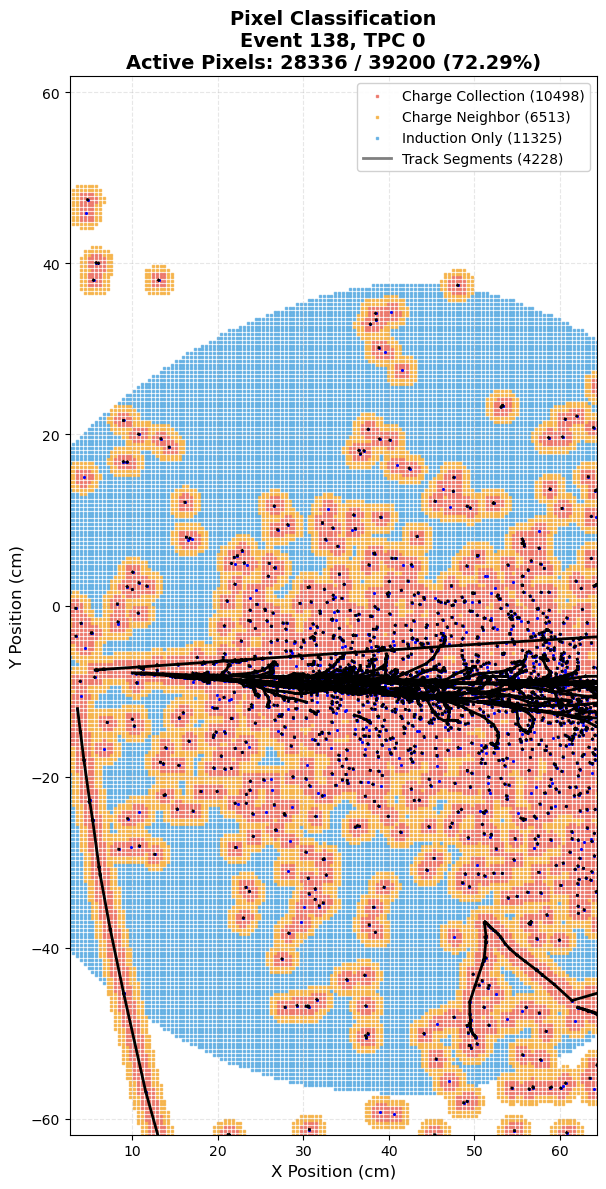


Visualization shows 28336 active pixels out of 39200 total pixels


<Figure size 640x480 with 0 Axes>

In [10]:
if len(segments) > 0:
    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=(16, 12))
    
    # Define colors for each category
    colors = {
        'charge': '#e74c3c',      # Red for charge collection
        'neighbor': '#f39c12',    # Orange for charge neighbor
        'induction': '#3498db',   # Blue for induction only
        'segment': 'black'      
    }

    _, px_charge, py_charge = pixel_ids_to_xy_for_plane(charge_pixels_np, plane_id)
    _, px_neighbor, py_neighbor = pixel_ids_to_xy_for_plane(neighbor_pixels_np, plane_id)
    _, px_induction, py_induction = pixel_ids_to_xy_for_plane(induction_pixels_np, plane_id)
    
    # Plot pixels by category (smaller markers for real data)
    marker_size = 3
    
    if len(charge_pixels_np) > 0:
        ax.scatter(px_charge, py_charge, 
                   c=colors['charge'], s=marker_size, alpha=0.6, 
                   label=f'Charge Collection ({len(charge_pixels_np)})', marker='s')
    
    if len(neighbor_pixels_np) > 0:
        ax.scatter(px_neighbor, py_neighbor, 
                   c=colors['neighbor'], s=marker_size, alpha=0.6, 
                   label=f'Charge Neighbor ({len(neighbor_pixels_np)})', marker='s')
    
    if len(induction_pixels_np) > 0:
        ax.scatter(px_induction, py_induction, 
                   c=colors['induction'], s=marker_size, alpha=0.6, 
                   label=f'Induction Only ({len(induction_pixels_np)})', marker='s')
    
    # For few segments, plot individually with visible thickness
    for i, seg in enumerate(segments):
        if seg['n_electrons'] < 0.01:
            continue
        ax.plot([seg['x_start'], seg['x_end']], [seg['y_start'], seg['y_end']], 
                c=colors['segment'], linewidth=2, alpha=1)
        ax.scatter(seg['x_start'], seg['y_start'], c='b', s=1)
        ax.scatter(seg['x_end'], seg['y_end'], c='b', s=1)
    
    # Add segment line to legend
    ax.plot([], [], c=colors['segment'], linewidth=2, alpha=0.5, 
           label=f'Track Segments ({len(segments)})')
    
    # Set labels and title
    n_active = len(charge_pixels_np) + len(neighbor_pixels_np) + len(induction_pixels_np)
    ax.set_xlabel('X Position (cm)', fontsize=12)
    ax.set_ylabel('Y Position (cm)', fontsize=12)
    ax.set_title(f'Pixel Classification\n'
                 f'Event {event_id}, TPC {plane_id}\n'
                 f'Active Pixels: {n_active} / {len(px_np)} '
                 f'({100*n_active/len(px_np):.2f}%)',
                 fontsize=14, fontweight='bold')
    
    # Add grid
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Legend
    ax.legend(fontsize=10, framealpha=0.9)
    ax.set_xlim([min(pixel_coords_x), max(pixel_coords_x)])
    ax.set_ylim([min(pixel_coords_y), max(pixel_coords_y)])
    
    # Equal aspect ratio
    ax.set_aspect('equal', adjustable='box')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nVisualization shows {n_active} active pixels out of {len(px_np)} total pixels")

    plt.savefig('pixel_classification.png')